In [5]:
## 0. Librerías y configuración

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score,
    precision_score, recall_score, f1_score, accuracy_score
)
from scipy import stats

# Statsmodels
import statsmodels.api as sm

# Configuración general de gráficos
plt.rcParams['figure.dpi']        = 130
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid']         = True
plt.rcParams['grid.linestyle']    = '--'
plt.rcParams['grid.alpha']        = 0.35

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.4f}'.format)

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [6]:
# ----- Rutas -----
import os
RUTA = r'C:\Users\juanc\OneDrive\Escritorio\SQL Training\Big Data y Machine Learning\TP4'

RUTA_2024 = os.path.join(RUTA, 'usu_individual_T324.xlsx')
RUTA_2025 = os.path.join(RUTA, 'usu_individual_T325.xlsx')

print('Ruta 2024 T3:', RUTA_2024)
print('Ruta 2025 T3:', RUTA_2025)

Ruta 2024 T3: C:\Users\juanc\OneDrive\Escritorio\SQL Training\Big Data y Machine Learning\TP4\usu_individual_T324.xlsx
Ruta 2025 T3: C:\Users\juanc\OneDrive\Escritorio\SQL Training\Big Data y Machine Learning\TP4\usu_individual_T325.xlsx


In [7]:
# ----- Variables a seleccionar (igual que TP3) -----
VARS = [
    'CODUSU', 'ANO4', 'TRIMESTRE', 'NRO_HOGAR', 'COMPONENTE', 'PONDERA',
    'CH03', 'CH04', 'CH06', 'CH07', 'CH08',
    'NIVEL_ED', 'ESTADO', 'CAT_OCUP',
    'PP04C', 'PP04D_COD', 'PP07H',
    'PP3E_TOT', 'PP3F_TOT',
    'P21', 'P47T',
    'CH12', 'CH13', 'CH14',
]

# Carga
eph_2024_raw = pd.read_excel(RUTA_2024)
eph_2025_raw = pd.read_excel(RUTA_2025)

print(f'EPH 2024 T3: {eph_2024_raw.shape[0]:,} personas | {eph_2024_raw.shape[1]} variables')
print(f'EPH 2025 T3: {eph_2025_raw.shape[0]:,} personas | {eph_2025_raw.shape[1]} variables')

vars_2024 = [v for v in VARS if v in eph_2024_raw.columns]
vars_2025 = [v for v in VARS if v in eph_2025_raw.columns]

df_2024 = eph_2024_raw[vars_2024].copy()
df_2025 = eph_2025_raw[vars_2025].copy()

print(f'\nVariables seleccionadas — 2024: {len(vars_2024)} | 2025: {len(vars_2025)}')

EPH 2024 T3: 47,564 personas | 235 variables
EPH 2025 T3: 44,946 personas | 235 variables

Variables seleccionadas — 2024: 24 | 2025: 24


In [8]:
# Limpieza de ingresos: reemplazamos valores negativos en variables de ingreso
for df in [df_2024, df_2025]:
    for var in ['P21', 'P47T']:
        if var in df.columns:
            df[var] = pd.to_numeric(df[var], errors='coerce')
            df[var] = df[var].where(df[var] >= 0, np.nan)

# Cambiamos el formato de la variable CH08
for df in [df_2024, df_2025]:
    if 'CH08' in df.columns:
        df['CH08'] = pd.to_numeric(df['CH08'], errors='coerce').astype('Int64')

print('Limpieza de ingresos completada.')

Limpieza de ingresos completada.


In [9]:
# ----- Ajuste por inflación: convertimos ingresos de 2024 T3 a pesos de 2025 T3 usando IPC INDEC
IPC_2024T3 = 6871.0
IPC_2025T3 = 9200.4
FACTOR_IPC = IPC_2025T3 / IPC_2024T3

print(f'Factor de actualización: {FACTOR_IPC:.4f} ({(FACTOR_IPC-1)*100:.1f}% inflación 2024T3→2025T3)')

df_2024['P21_real']  = df_2024['P21']  * FACTOR_IPC
df_2024['P47T_real'] = df_2024['P47T'] * FACTOR_IPC
df_2025['P21_real']  = df_2025['P21']
df_2025['P47T_real'] = df_2025['P47T']

Factor de actualización: 1.3390 (33.9% inflación 2024T3→2025T3)


In [10]:
# ----- Etiqueta de año y concatenación -----
df_2024['año'] = 2024
df_2025['año'] = 2025

df_total = pd.concat([df_2024, df_2025], ignore_index=True)
print(f'Base total combinada: {len(df_total):,} personas')

Base total combinada: 92,510 personas


In [12]:
# ----- Variables derivadas (igual que TP3) -----

# Filtramos respondieron (ESTADO != 0)
respondieron = df_total[df_total['ESTADO'] != 0].copy()

# edad y edad²
respondieron['edad'] = pd.to_numeric(respondieron['CH06'], errors='coerce')
respondieron['edad'] = respondieron['edad'].where(
    (respondieron['edad'] >= 0) & (respondieron['edad'] <= 120), np.nan
)
respondieron['edad2'] = respondieron['edad'] ** 2

# educ: años de educación formal
años_base = {1:0, 2:0, 3:0, 4:7, 5:9, 6:12, 7:12, 8:17, 9:0}
años_max  = {1:1, 2:7, 3:9, 4:5, 5:3, 6:5,  7:5,  8:5,  9:0}

def calcular_educ(row):
    try:
        nivel    = int(pd.to_numeric(row.get('CH12', 0), errors='coerce') or 0)
        completo = int(pd.to_numeric(row.get('CH13', 2), errors='coerce') or 2)
        ultimo   = pd.to_numeric(row.get('CH14', 0), errors='coerce')
        ultimo   = 0 if pd.isna(ultimo) else int(ultimo)
        base     = años_base.get(nivel, 0)
        maximo   = años_max.get(nivel, 0)
        if completo == 1:
            return base + maximo
        else:
            return base + min(ultimo, maximo)
    except:
        return np.nan

respondieron['educ'] = respondieron.apply(calcular_educ, axis=1)

# horastrab: horas trabajadas (solo jefe de hogar, CH03==1)
respondieron['PP3E_TOT'] = pd.to_numeric(respondieron['PP3E_TOT'], errors='coerce').replace(999, np.nan)
respondieron['PP3F_TOT'] = pd.to_numeric(respondieron['PP3F_TOT'], errors='coerce').replace(999, np.nan).fillna(0)
es_jefe = pd.to_numeric(respondieron['CH03'], errors='coerce') == 1
respondieron['horastrab'] = np.where(
    es_jefe,
    respondieron['PP3E_TOT'] + respondieron['PP3F_TOT'],
    np.nan
)

# nhogar: número de miembros del hogar
id_cols = ['CODUSU', 'NRO_HOGAR']
nhogar_df = (
    respondieron
    .groupby(id_cols)['COMPONENTE']
    .count()
    .reset_index()
    .rename(columns={'COMPONENTE': 'nhogar'})
)
respondieron = respondieron.merge(nhogar_df, on=id_cols, how='left')

print('Variables derivadas creadas: edad, edad2, educ, horastrab, nhogar')

Variables derivadas creadas: edad, edad2, educ, horastrab, nhogar


In [15]:
# ----- Indicador de informalidad (Upper-tier informal) -----
# Definición Grupo 1:
#   1 = upper-tier informal: asalariado (CAT_OCUP=3) + no aporta jubilación (PP07H=2) + empresa >5 personas (PP04C≥6)
#   0 = formal: asalariado con jubilación (PP07H=1)
#   NaN = no aplica

def crear_indicador_informalidad(df):
    df = df.copy()
    for col in ['CAT_OCUP', 'PP07H', 'PP04C']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    def clasificar(row):
        if row.get('CAT_OCUP', np.nan) != 3:
            return np.nan
        if row.get('PP07H', np.nan) not in [1, 2]:
            return np.nan
        if row.get('PP07H', np.nan) == 1:
            return 0
        pp04c = row.get('PP04C', np.nan)
        if pd.isna(pp04c) or pp04c == 99:
            return np.nan
        return 1 if pp04c >= 6 else 0

    df['informal'] = df.apply(clasificar, axis=1)
    return df

# Base ocupados: ESTADO == 1
ocupados = respondieron[respondieron['ESTADO'] == 1].copy()
ocupados = crear_indicador_informalidad(ocupados)

print(f'Ocupados total (2024+2025): {len(ocupados):,}')
print('\nDistribución por año e informalidad:')
print(
    ocupados[ocupados['informal'].notna()]
    .groupby(['año', 'informal'])
    .size()
    .rename({0: 'Formal', 1: 'Upper-tier informal'})
    .unstack()
)

Ocupados total (2024+2025): 41,097

Distribución por año e informalidad:
informal  Formal  Upper-tier informal
año                                  
2024       12871                 1602
2025       12102                 1443


---
## Inciso A — Enfoque de validación: 2024 T3 como entrenamiento, 2025 T3 como testeo

### A.1 — Separación de la base

In [16]:
# Variables características X (las mismas del TP3)
VARS_X = ['edad', 'edad2', 'educ', 'horastrab', 'nhogar', 'P21_real', 'PP04C']

# Nos quedamos solo con asalariados que tienen el indicador definido
asal = ocupados[
    (ocupados['CAT_OCUP'] == 3) &
    (ocupados['informal'].notna())
].copy()

# Separamos por año
asal_2024 = asal[asal['año'] == 2024].copy()
asal_2025 = asal[asal['año'] == 2025].copy()

print(f'Asalariados 2024 T3 (Formales + Upper-tier): {len(asal_2024):,}')
print(f'Asalariados 2025 T3 (Formales + Upper-tier): {len(asal_2025):,}')

Asalariados 2024 T3 (Formales + Upper-tier): 14,473
Asalariados 2025 T3 (Formales + Upper-tier): 13,545


In [17]:
# Quitamos filas sin NaN en ninguna variable X ni en y
# Filtramos y reseteamos el índice

cols_modelo = VARS_X + ['informal', 'CODUSU', 'NRO_HOGAR', 'COMPONENTE']

asal_2024_clean = asal_2024[cols_modelo].dropna().reset_index(drop=True)
asal_2025_clean = asal_2025[cols_modelo].dropna().reset_index(drop=True)

# Matrices X y vectores y
ocupados_X_2024 = asal_2024_clean[VARS_X].copy()
ocupados_X_2025 = asal_2025_clean[VARS_X].copy()

y_2024 = asal_2024_clean['informal'].copy()
y_2025 = asal_2025_clean['informal'].copy()

print(f'ocupados_X_2024: {ocupados_X_2024.shape}  |  y_2024: {y_2024.shape}')
print(f'ocupados_X_2025: {ocupados_X_2025.shape}  |  y_2025: {y_2025.shape}')
print(f'\nDistribución y_2024 — Formales: {(y_2024==0).sum():,} | Upper-tier informales: {(y_2024==1).sum():,}')
print(f'Distribución y_2025 — Formales: {(y_2025==0).sum():,} | Upper-tier informales: {(y_2025==1).sum():,}')

ocupados_X_2024: (6196, 7)  |  y_2024: (6196,)
ocupados_X_2025: (5686, 7)  |  y_2025: (5686,)

Distribución y_2024 — Formales: 5,599 | Upper-tier informales: 597
Distribución y_2025 — Formales: 5,144 | Upper-tier informales: 542


In [18]:
# ----- Inner join para construir ocupados_X_2025_MM -----
# y_2024 como variable explicativa en el modelo 2025 siguendo lineamiento de Maurizio & Monsalvo (2021): 
# la informalidad pasada predice la informalidad presente.

# Preparamos la tabla de 2024 con solo las columnas de identificación y y_2024
df_2024_join = asal_2024_clean[['CODUSU', 'NRO_HOGAR', 'COMPONENTE', 'informal']].copy()
df_2024_join = df_2024_join.rename(columns={'informal': 'informal_2024'})

# Preparamos la tabla de 2025 con X + y + identificadores
df_2025_join = asal_2025_clean[VARS_X + ['informal', 'CODUSU', 'NRO_HOGAR', 'COMPONENTE']].copy()

# Inner join
ocupados_X_2025_MM = df_2025_join.merge(
    df_2024_join,
    on=['CODUSU', 'NRO_HOGAR', 'COMPONENTE'],
    how='inner'
)

n_2025_total   = len(asal_2025_clean)
n_2025_matched = len(ocupados_X_2025_MM)
pct_matched    = n_2025_matched / n_2025_total * 100

print(f'Asalariados 2025 T3 totales:         {n_2025_total:,}')
print(f'Asalariados 2025 T3 con match 2024:  {n_2025_matched:,} ({pct_matched:.1f}%)')
print(f'\nEstructura de ocupados_X_2025_MM: {ocupados_X_2025_MM.shape}')

# Eliminamos las columnas de identificación (ya no las necesitamos)
ocupados_X_2025_MM = ocupados_X_2025_MM.drop(columns=['CODUSU', 'NRO_HOGAR', 'COMPONENTE'])

print('\nColumnas de ocupados_X_2025_MM:')
print(list(ocupados_X_2025_MM.columns))
print(f'\nEstructura de ocupados_X_2025_MM: {ocupados_X_2025_MM.shape}')

Asalariados 2025 T3 totales:         5,686
Asalariados 2025 T3 con match 2024:  1,781 (31.3%)

Estructura de ocupados_X_2025_MM: (1781, 12)

Columnas de ocupados_X_2025_MM:
['edad', 'edad2', 'educ', 'horastrab', 'nhogar', 'P21_real', 'PP04C', 'informal', 'informal_2024']

Estructura de ocupados_X_2025_MM: (1781, 9)


### A.2 — Tabla de diferencia de medias: 2024 vs 2025

In [26]:
# Tabla de diferencia de medias (t-test de Student bilateral)
filas = []

for var in VARS_X:
    x_2024 = ocupados_X_2024[var].dropna()
    x_2025 = ocupados_X_2025[var].dropna()

    media_2024 = x_2024.mean()
    media_2025 = x_2025.mean()
    diferencia = media_2025 - media_2024

    t_stat, p_val = stats.ttest_ind(x_2024, x_2025, equal_var=False)  # Welch's t-test
    significativo = 'Sí ***' if p_val < 0.01 else ('Sí **' if p_val < 0.05 else ('Sí *' if p_val < 0.10 else 'No'))

    filas.append({
        'Variable': var,
        'Media 2024 T3': media_2024,
        'Media 2025 T3': media_2025,
        'Diferencia (2025-2024)': diferencia,
        'p-valor': p_val,
        'Sig. estadística': significativo
    })

tabla_medias = pd.DataFrame(filas).set_index('Variable')

print('=== Tabla de diferencia de medias: 2024 T3 vs 2025 T3 ===')
print('(* p<0.10  ** p<0.05  *** p<0.01 — Welch t-test bilateral)')
print()
print(tabla_medias.round(4).to_string())
print(f'\nN — 2024 T3: {len(ocupados_X_2024):,} | 2025 T3: {len(ocupados_X_2025):,}')

=== Tabla de diferencia de medias: 2024 T3 vs 2025 T3 ===
(* p<0.10  ** p<0.05  *** p<0.01 — Welch t-test bilateral)

           Media 2024 T3  Media 2025 T3  Diferencia (2025-2024)  p-valor Sig. estadística
Variable                                                                                 
edad             43.8052        44.4573                  0.6521   0.0021           Sí ***
edad2         2,052.0295     2,109.7140                 57.6845   0.0029           Sí ***
educ             12.7201        12.7594                  0.0393   0.5735               No
horastrab        38.0005        38.3922                  0.3917   0.1973               No
nhogar            4.2335         4.2628                  0.0292   0.5774               No
P21_real    878,621.1370 1,013,514.6205            134,893.4835   0.0000           Sí ***
PP04C            14.6035        15.0445                  0.4410   0.3595               No

N — 2024 T3: 6,196 | 2025 T3: 5,686


---
## Inciso B — Modelo de Regresión Logística

In [19]:
# ---- Modelo 1: entrenamiento en 2024 ----
# X con constante (statsmodels no la agrega automáticamente)
X1 = sm.add_constant(ocupados_X_2024)
Y1 = y_2024.astype(float)

logit_1 = sm.Logit(Y1, X1).fit(disp=False)
print('=== Modelo 1: 2024 T3 (train en 2024) ===')
print(logit_1.summary2())

=== Modelo 1: 2024 T3 (train en 2024) ===
                         Results: Logit
Model:              Logit            Method:           MLE       
Dependent Variable: informal         Pseudo R-squared: 0.082     
Date:               2026-05-29 10:27 AIC:              3622.1016 
No. Observations:   6196             BIC:              3675.9549 
Df Model:           7                Log-Likelihood:   -1803.1   
Df Residuals:       6188             LL-Null:          -1964.1   
Converged:          1.0000           LLR p-value:      1.1546e-65
No. Iterations:     7.0000           Scale:            1.0000    
------------------------------------------------------------------
               Coef.   Std.Err.     z     P>|z|    [0.025   0.975]
------------------------------------------------------------------
const          1.4958    0.4936   3.0303  0.0024   0.5283   2.4633
edad          -0.1095    0.0233  -4.7051  0.0000  -0.1551  -0.0639
edad2          0.0009    0.0003   3.3751  0.0007   0.00

In [20]:
# ---- Modelo 2 (MM): entrenamiento en 2024, con lagged informality ----
# La variable informal_2024 captura la persistencia de la informalidad

VARS_X_MM = VARS_X + ['informal_2024']

# Separamos X e y del dataframe conjunto
X2_df = ocupados_X_2025_MM[VARS_X_MM].copy()
Y2    = ocupados_X_2025_MM['informal'].astype(float)

X2 = sm.add_constant(X2_df)

logit_2 = sm.Logit(Y2, X2).fit(disp=False)
print('=== Modelo 2 (MM): 2025 T3 con informalidad previa de 2024 ===')
print(logit_2.summary2())

=== Modelo 2 (MM): 2025 T3 con informalidad previa de 2024 ===
                         Results: Logit
Model:              Logit            Method:           MLE       
Dependent Variable: informal         Pseudo R-squared: 0.361     
Date:               2026-05-29 10:27 AIC:              635.5435  
No. Observations:   1781             BIC:              684.9078  
Df Model:           8                Log-Likelihood:   -308.77   
Df Residuals:       1772             LL-Null:          -482.99   
Converged:          1.0000           LLR p-value:      1.9559e-70
No. Iterations:     9.0000           Scale:            1.0000    
-----------------------------------------------------------------
                   Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
-----------------------------------------------------------------
const              1.1129   1.5611  0.7129 0.4759 -1.9469  4.1727
edad              -0.1545   0.0708 -2.1811 0.0292 -0.2934 -0.0157
edad2              0.0014   0.0008  1.8

In [21]:
# ---- Tabla comparativa: coeficientes, errores estándar y odds-ratios ----
# Incluimos solo las variables que están en ambos modelos para la comparación directa

def tabla_logit(modelo, nombre):
    coef = modelo.params
    se   = modelo.bse
    pval = modelo.pvalues
    or_  = np.exp(coef)  # odds-ratio = exp(coeficiente)
    df = pd.DataFrame({
        f'Coef ({nombre})': coef,
        f'SE ({nombre})':   se,
        f'OR ({nombre})':   or_,
        f'p-valor ({nombre})': pval
    })
    return df

tab1 = tabla_logit(logit_1, 'M1')
tab2 = tabla_logit(logit_2, 'M2')

tabla_comparativa = tab1.join(tab2, how='outer')

print('=== Tabla comparativa: Modelos 1 y 2 ===')
print('(OR = odds-ratio = exp(coef); OR>1 aumenta chances de ser informal)')
print()
print(tabla_comparativa.round(4).to_string())

=== Tabla comparativa: Modelos 1 y 2 ===
(OR = odds-ratio = exp(coef); OR>1 aumenta chances de ser informal)

               Coef (M1)  SE (M1)  OR (M1)  p-valor (M1)  Coef (M2)  SE (M2)  OR (M2)  p-valor (M2)
P21_real         -0.0000   0.0000   1.0000        0.0000    -0.0000   0.0000   1.0000        0.3656
PP04C            -0.0146   0.0031   0.9855        0.0000    -0.0245   0.0092   0.9758        0.0081
const             1.4958   0.4936   4.4631        0.0024     1.1129   1.5611   3.0431        0.4759
edad             -0.1095   0.0233   0.8963        0.0000    -0.1545   0.0708   0.8568        0.0292
edad2             0.0009   0.0003   1.0009        0.0007     0.0014   0.0008   1.0014        0.0684
educ             -0.0090   0.0131   0.9910        0.4905    -0.0508   0.0320   0.9504        0.1124
horastrab         0.0039   0.0028   1.0039        0.1635     0.0089   0.0072   1.0090        0.2140
informal_2024        NaN      NaN      NaN           NaN     3.6990   0.2302  40.4089     

In [22]:
# ---- Efectos marginales (en la media) ----
me1 = logit_1.get_margeff()
me2 = logit_2.get_margeff()

print('=== Efectos Marginales Medios — Modelo 1 (2024) ===')
print(me1.summary())
print()
print('=== Efectos Marginales Medios — Modelo 2 MM (2025) ===')
print(me2.summary())

=== Efectos Marginales Medios — Modelo 1 (2024) ===
        Logit Marginal Effects       
Dep. Variable:               informal
Method:                          dydx
At:                           overall
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
edad          -0.0090      0.002     -4.708      0.000      -0.013      -0.005
edad2       7.397e-05   2.19e-05      3.378      0.001     3.1e-05       0.000
educ          -0.0007      0.001     -0.690      0.490      -0.003       0.001
horastrab      0.0003      0.000      1.392      0.164      -0.000       0.001
nhogar         0.0019      0.001      1.495      0.135      -0.001       0.004
P21_real   -9.594e-08   1.02e-08     -9.441      0.000   -1.16e-07    -7.6e-08
PP04C         -0.0012      0.000     -4.734      0.000      -0.002      -0.001

=== Efectos Marginales Medios — Modelo 2 MM (2025) ===
        Logit Marginal Effect

### B.2 — Visualización: probabilidad predicha de ser informal vs una variable numérica

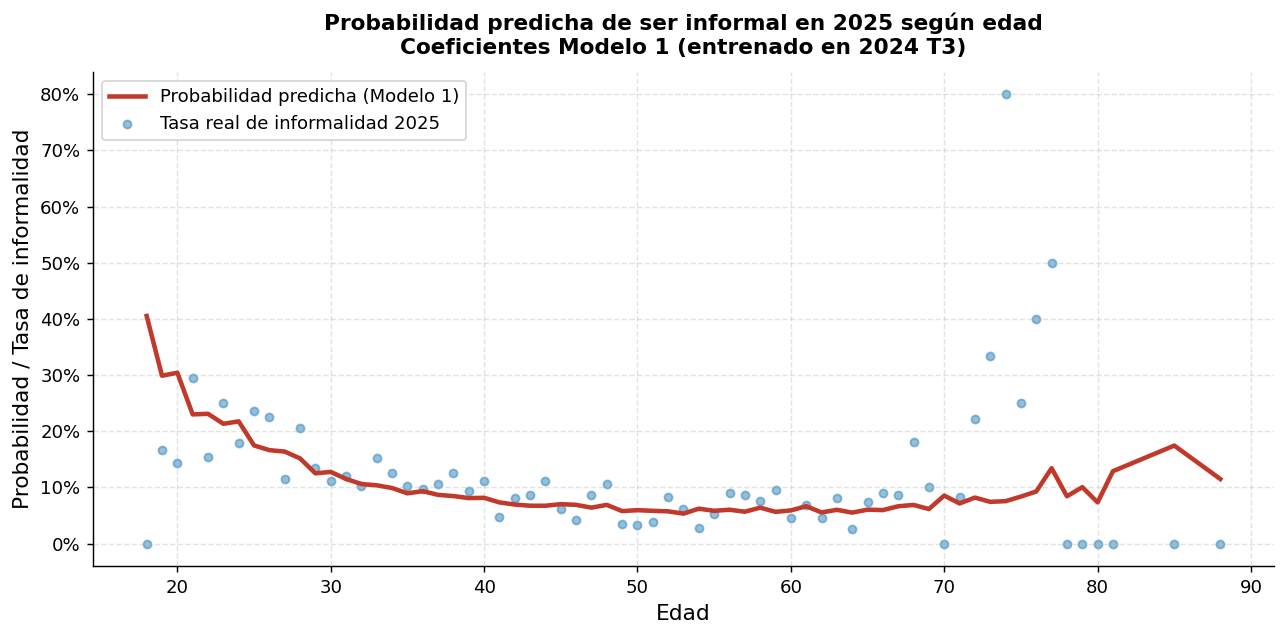

Guardado: B2_prob_edad.png


In [23]:
# Graficamos la probabilidad predicha de ser informal en 2025 contra la edad,
# usando los coeficientes del Modelo 1 (estimado en 2024) aplicados a datos de 2025.

# Para poder aplicar el Modelo 1 (que no tiene informal_2024) a los datos de 2025_MM,
# usamos ocupados_X_2025 (base completa de 2025, sin el join).

# Calculamos probabilidades predichas del Modelo 1 sobre los datos de 2025
X_2025_pred = sm.add_constant(ocupados_X_2025, has_constant='add')
prob_pred_2025 = logit_1.predict(X_2025_pred)

# Armamos un dataframe para graficar
df_plot = ocupados_X_2025.copy()
df_plot['prob_informal'] = prob_pred_2025
df_plot['y_2025']        = y_2025.values

# Agrupamos por edad y tomamos la probabilidad media predicha
plot_edad = (
    df_plot.groupby('edad')[['prob_informal', 'y_2025']]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    plot_edad['edad'], plot_edad['prob_informal'],
    color='#C0392B', linewidth=2.5, label='Probabilidad predicha (Modelo 1)'
)
ax.scatter(
    plot_edad['edad'], plot_edad['y_2025'],
    color='#2980B9', alpha=0.5, s=20, label='Tasa real de informalidad 2025'
)

ax.set_xlabel('Edad', fontsize=12)
ax.set_ylabel('Probabilidad / Tasa de informalidad', fontsize=12)
ax.set_title(
    'Probabilidad predicha de ser informal en 2025 según edad\n'
    'Coeficientes Modelo 1 (entrenado en 2024 T3)',
    fontsize=12, fontweight='bold', pad=10
)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=0))
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(RUTA, 'B2_prob_edad.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: B2_prob_edad.png')

---
## Inciso D — Desempeño del modelo y predicción fuera de muestra

In [24]:
# ---- Predicciones ----

# Modelo 1: predice sobre 2025 completo
prob_m1 = logit_1.predict(sm.add_constant(ocupados_X_2025, has_constant='add'))
pred_m1 = (prob_m1 >= 0.5).astype(int)
real_m1 = y_2025.astype(int)

# Modelo 2 (MM): predice sobre 2025_MM
X2_test  = sm.add_constant(ocupados_X_2025_MM[VARS_X_MM], has_constant='add')
prob_m2  = logit_2.predict(X2_test)
pred_m2  = (prob_m2 >= 0.5).astype(int)
real_m2  = ocupados_X_2025_MM['informal'].astype(int)

print(f'Modelo 1 — observaciones evaluadas: {len(pred_m1):,}')
print(f'Modelo 2 — observaciones evaluadas: {len(pred_m2):,}')

Modelo 1 — observaciones evaluadas: 5,686
Modelo 2 — observaciones evaluadas: 1,781


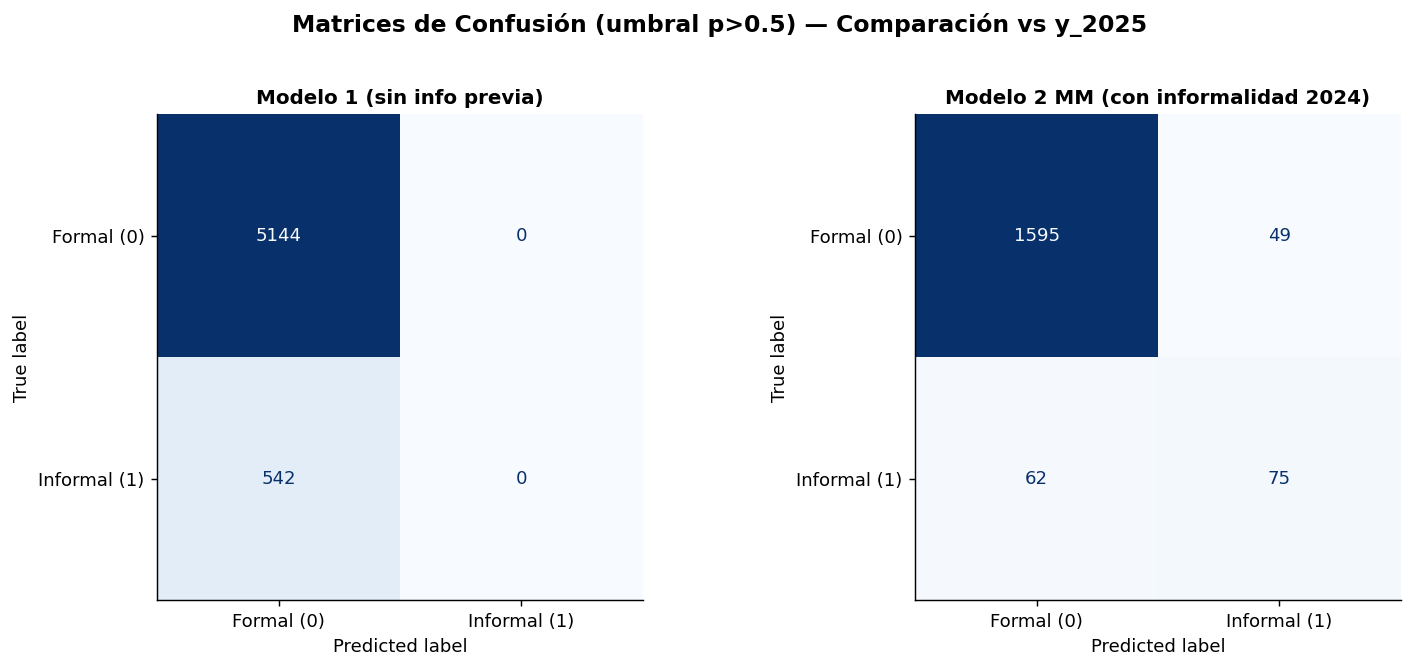

Guardado: D_confusion.png


In [25]:
# ---- Matrices de confusión ----
# Filas = real | Columnas = predicho
# TN (formal predicho formal) | FP (formal predicho informal)
# FN (informal predicho formal) | TP (informal predicho informal)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, real, pred, titulo in zip(
    axes,
    [real_m1, real_m2],
    [pred_m1, pred_m2],
    ['Modelo 1 (sin info previa)', 'Modelo 2 MM (con informalidad 2024)']
):
    cm = confusion_matrix(real, pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Formal (0)', 'Informal (1)']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.grid(False)

plt.suptitle('Matrices de Confusión (umbral p>0.5) — Comparación vs y_2025',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RUTA, 'D_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: D_confusion.png')

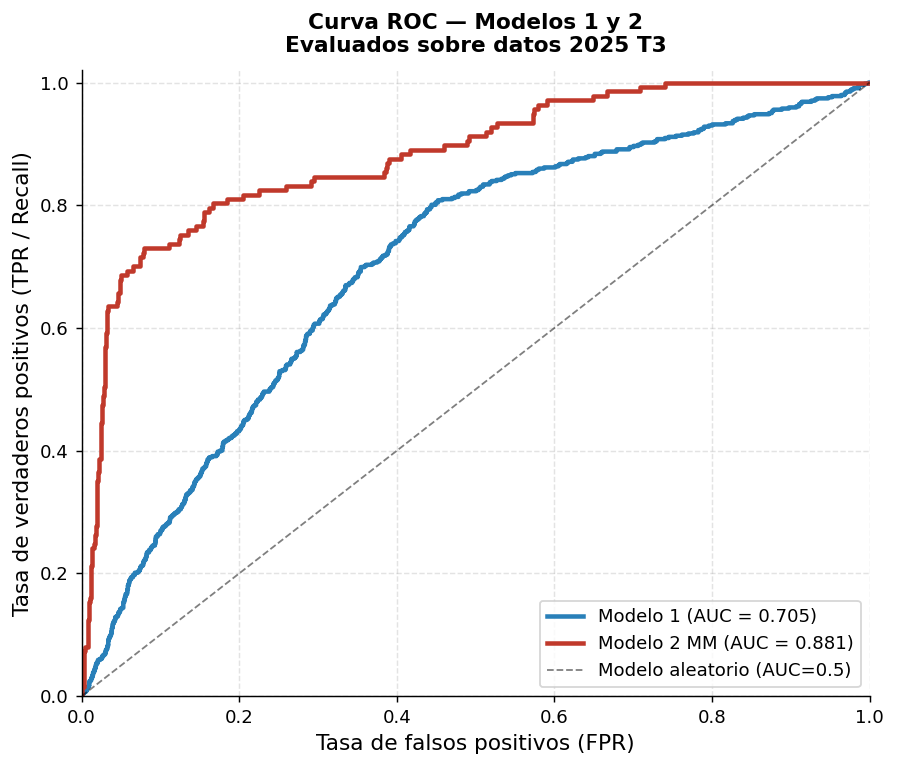

AUC Modelo 1: 0.7052
AUC Modelo 2: 0.8810


In [26]:
# ---- Curvas ROC ----
# La curva ROC grafica TPR (recall) vs FPR para todos los umbrales posibles.
#   AUC = 0.5 → modelo aleatorio | AUC = 1.0 → modelo perfecto

fpr_m1, tpr_m1, _ = roc_curve(real_m1, prob_m1)
fpr_m2, tpr_m2, _ = roc_curve(real_m2, prob_m2)

auc_m1 = roc_auc_score(real_m1, prob_m1)
auc_m2 = roc_auc_score(real_m2, prob_m2)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr_m1, tpr_m1, color='#2980B9', linewidth=2.5,
        label=f'Modelo 1 (AUC = {auc_m1:.3f})')
ax.plot(fpr_m2, tpr_m2, color='#C0392B', linewidth=2.5,
        label=f'Modelo 2 MM (AUC = {auc_m2:.3f})')
ax.plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Modelo aleatorio (AUC=0.5)')

ax.set_xlabel('Tasa de falsos positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de verdaderos positivos (TPR / Recall)', fontsize=12)
ax.set_title('Curva ROC — Modelos 1 y 2\nEvaluados sobre datos 2025 T3',
             fontsize=12, fontweight='bold', pad=10)
ax.legend(fontsize=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig(os.path.join(RUTA, 'D_roc.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'AUC Modelo 1: {auc_m1:.4f}')
print(f'AUC Modelo 2: {auc_m2:.4f}')

In [27]:
# ---- Métricas adicionales ----
# Además de AUC, calculamos Accuraccy, Precision, Recall y F1-score

def metricas(real, pred, prob, nombre):
    return {
        'Modelo': nombre,
        'Accuracy':   accuracy_score(real, pred),
        'Precision':  precision_score(real, pred, zero_division=0),
        'Recall (Sensibilidad)': recall_score(real, pred, zero_division=0),
        'F1-score':   f1_score(real, pred, zero_division=0),
        'AUC-ROC':    roc_auc_score(real, prob)
    }

tabla_metricas = pd.DataFrame([
    metricas(real_m1, pred_m1, prob_m1, 'Modelo 1 (sin info previa)'),
    metricas(real_m2, pred_m2, prob_m2, 'Modelo 2 MM (con informal_2024)')
]).set_index('Modelo')

print('=== Métricas de desempeño (umbral p>0.5) ===')
print(tabla_metricas.round(4).to_string())

=== Métricas de desempeño (umbral p>0.5) ===
                                 Accuracy  Precision  Recall (Sensibilidad)  F1-score  AUC-ROC
Modelo                                                                                        
Modelo 1 (sin info previa)         0.9047     0.0000                 0.0000    0.0000   0.7052
Modelo 2 MM (con informal_2024)    0.9377     0.6048                 0.5474    0.5747   0.8810
